In [2]:
import zipfile
import os

# Unzip train
with zipfile.ZipFile('/content/train.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Unzip test
with zipfile.ZipFile('/content/test.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Unzipping Done")


Unzipping Done


In [3]:
import os
import shutil
import random

In [4]:
def create_subset(src_dir, dst_dir, max_images=30000):
    os.makedirs(dst_dir, exist_ok=True)

    for cls in ["FAKE", "REAL"]:
        src_cls = os.path.join(src_dir, cls)
        dst_cls = os.path.join(dst_dir, cls)
        os.makedirs(dst_cls, exist_ok=True)

        images = os.listdir(src_cls)
        random.shuffle(images)
        selected = images[:max_images]

        for img in selected:
            shutil.copy(
                os.path.join(src_cls, img),
                os.path.join(dst_cls, img)
            )

# Create subset folder
subset_train_dir = "/content/train_subset"
create_subset("/content/train", subset_train_dir, max_images=30000)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [7]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

dataset = datasets.ImageFolder(root=subset_train_dir, transform=transform)
class_names = dataset.classes
print("Classes:", class_names)

Classes: ['FAKE', 'REAL']


In [8]:
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

In [9]:
model = models.regnet_y_400mf(
    weights=models.RegNet_Y_400MF_Weights.DEFAULT
)

# Replace classifier head
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/regnet_y_400mf-e6988f5f.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_400mf-e6988f5f.pth


100%|██████████| 16.8M/16.8M [00:00<00:00, 145MB/s]


In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [11]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [12]:
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            probs = torch.sigmoid(outputs)
            predictions = (probs > 0.5).int().cpu().numpy()

            preds.extend(predictions)
            targets.extend(labels.numpy())

    return np.array(preds), np.array(targets)

In [13]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_preds, val_targets = evaluate(model, val_loader)
    val_acc = accuracy_score(val_targets, val_preds)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Accuracy: {val_acc:.4f}")

Epoch [1/10] Train Loss: 0.5642 Val Accuracy: 0.8219
Epoch [2/10] Train Loss: 0.3461 Val Accuracy: 0.8811
Epoch [3/10] Train Loss: 0.2616 Val Accuracy: 0.9073
Epoch [4/10] Train Loss: 0.2165 Val Accuracy: 0.9200
Epoch [5/10] Train Loss: 0.1897 Val Accuracy: 0.9247
Epoch [6/10] Train Loss: 0.1698 Val Accuracy: 0.9289
Epoch [7/10] Train Loss: 0.1429 Val Accuracy: 0.9337
Epoch [8/10] Train Loss: 0.1260 Val Accuracy: 0.9366
Epoch [9/10] Train Loss: 0.1135 Val Accuracy: 0.9385
Epoch [10/10] Train Loss: 0.1002 Val Accuracy: 0.9446


In [14]:
test_dataset = datasets.ImageFolder(
    root="/content/test",
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

test_preds, test_targets = evaluate(model, test_loader)

accuracy  = accuracy_score(test_targets, test_preds)
precision = precision_score(test_targets, test_preds)
recall    = recall_score(test_targets, test_preds)
f1        = f1_score(test_targets, test_preds)

print("Test Results:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Test Results:
Accuracy : 0.9446
Precision: 0.9406
Recall   : 0.9490
F1-score : 0.9448


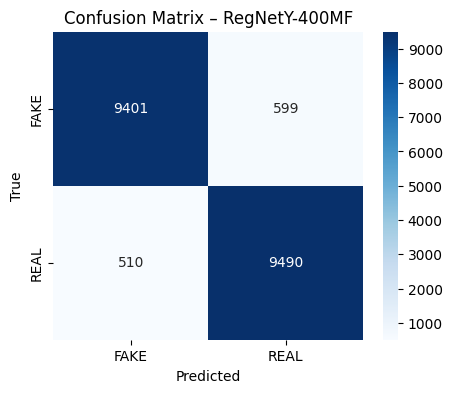

In [15]:
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – RegNetY-400MF")
plt.show()

In [16]:
from sklearn.metrics import classification_report

In [17]:
print(
    classification_report(
        test_targets,
        test_preds,
        target_names=["fake", "real"],
        digits=4
    )
)

              precision    recall  f1-score   support

        fake     0.9485    0.9401    0.9443     10000
        real     0.9406    0.9490    0.9448     10000

    accuracy                         0.9446     20000
   macro avg     0.9446    0.9446    0.9445     20000
weighted avg     0.9446    0.9446    0.9445     20000



##PHASE 2

In [21]:
model = models.efficientnet_b0(weights=None)
# Change the output features to 2 to match the checkpoint, assuming it was trained for 2 classes.
# If you intend for binary classification with a single output neuron, you'll need a different checkpoint
# or to train a model with a single output neuron from scratch.
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

model.load_state_dict(torch.load("/efficientnet_cifake.pth", map_location=device))
model = model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [22]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

test_dataset = datasets.ImageFolder("/content/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [23]:
print(test_dataset.class_to_idx)
# Expect: {'fake': 0, 'real': 1}

{'FAKE': 0, 'REAL': 1}


In [26]:
def predict_confidence(model, image_tensor):
    image_tensor = image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(image_tensor)
        # The model now outputs two logits (one for FAKE and one for REAL).
        # Assuming index 1 corresponds to the 'REAL' class probability.
        prob = torch.sigmoid(logit[0, 1]).item()
    return prob

In [27]:
high_conf_fakes = []

for img, label in test_loader:
    if label.item() == 0:  # fake
        real_prob = predict_confidence(model, img[0])
        fake_prob = 1 - real_prob

        if fake_prob > 0.9:
            high_conf_fakes.append((img[0], fake_prob))

    if len(high_conf_fakes) == 5:
        break

print(f"Selected {len(high_conf_fakes)} high-confidence fake images")

Selected 5 high-confidence fake images


In [28]:
def gaussian_blur(img_tensor, sigma):
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)

    blurred = cv2.GaussianBlur(img, (3,3), sigmaX=sigma)

    blurred = blurred / 255.0
    blurred = (blurred - 0.5) / 0.5
    return torch.tensor(blurred).permute(2,0,1).float()

In [29]:
def jpeg_compress(img_tensor, quality):
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encimg = cv2.imencode('.jpg', img, encode_param)
    decimg = cv2.imdecode(encimg, 1)

    decimg = decimg / 255.0
    decimg = (decimg - 0.5) / 0.5
    return torch.tensor(decimg).permute(2,0,1).float()

In [81]:
import cv2

img, orig_fake_conf = high_conf_fakes[0]

steps = [
    ("Original", img),
    ("Blur σ=0.9", gaussian_blur(img, 0.7)),
    ("Blur σ=0.5", gaussian_blur(img, 0.5)),
    ("JPEG Q=70", jpeg_compress(img, 70)),
]

results = []

for name, step_img in steps:
    real_prob = predict_confidence(model, step_img)
    fake_prob = 1 - real_prob
    results.append((name, fake_prob))

In [82]:
for name, conf in results:
    print(f"{name}: Fake confidence = {conf:.4f}")

Original: Fake confidence = 0.9673
Blur σ=0.9: Fake confidence = 0.5212
Blur σ=0.5: Fake confidence = 0.0002
JPEG Q=70: Fake confidence = 0.6869


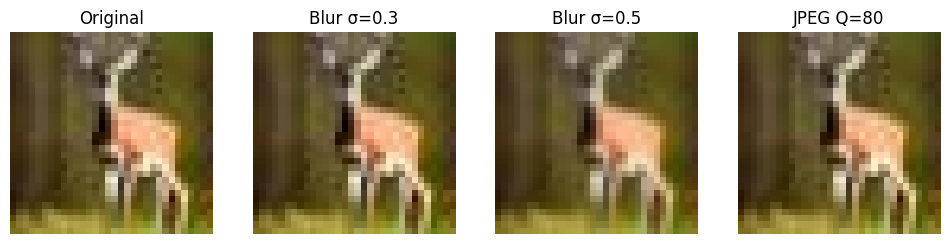

In [58]:
plt.figure(figsize=(12,3))
for i, (name, step_img) in enumerate(steps):
    plt.subplot(1,4,i+1)
    img_np = step_img.permute(1,2,0).cpu().numpy()
    img_np = (img_np * 0.5 + 0.5)
    plt.imshow(img_np)
    plt.title(name)
    plt.axis("off")
plt.show()

In [43]:
import cv2

img, orig_fake_conf = high_conf_fakes[0]

steps = [
    ("Original", img),
    ("Blur σ=0.3", gaussian_blur(img, 0.3)),
    ("Blur σ=0.5", gaussian_blur(img, 0.5)),
    ("JPEG Q=80", jpeg_compress(img, 80)),
]

results = []

for name, step_img in steps:
    real_prob = predict_confidence(model, step_img)
    fake_prob = 1 - real_prob
    results.append((name, fake_prob))

In [44]:
for name, conf in results:
    print(f"{name}: Fake confidence = {conf:.4f}")

Original: Fake confidence = 0.9673
Blur σ=0.3: Fake confidence = 0.9418
Blur σ=0.5: Fake confidence = 0.0002
JPEG Q=80: Fake confidence = 0.0006
